# CEXI Model Tutorial

**CEXI** (Cellular Exchange Imaging) models the diffusion-MRI signal of tissue as
water exchanging between two compartments:

- an **intracellular** compartment — water restricted inside spherical cells, and
- an **extracellular** compartment — water diffusing in the hindered space around them,

with **water exchange** across the (permeable) cell membranes.

This tutorial explains the model and its parameters, shows how to synthesize the
signal for a given acquisition protocol, and how to fit the model back to data.

> Reference: Gardier R. *et al.* *Cellular Exchange Imaging (CEXI): evaluation of a
> diffusion model including water exchange in cells using numerical phantoms of
> permeable spheres.* Magn Reson Med. 2023;90(4):1625-1640.

## 1. The model

For a pulsed-gradient (PGSE) measurement with b-value $b$, the CEXI signal is a
two-compartment **Kärger exchange** model:

$$ S(b) \;=\; f_1'\,e^{-b\,D_1'} \;+\; f_2'\,e^{-b\,D_2'} $$

where $D_{1,2}'$ and $f_{1,2}'$ are the *apparent* diffusivities and fractions
produced by exchange between the two underlying compartments:

- **Intracellular** — restricted diffusion inside a sphere of radius $R$ and
  intrinsic diffusivity $D_i$. The restricted signal is computed with the
  van Gelderen / Gaussian-Phase-Distribution (GPD) series, giving an apparent
  intracellular diffusivity $D_{i,\mathrm{app}}(b)= -\ln S_{\mathrm{sphere}}(b)/b$.
- **Extracellular** — Gaussian (hindered) diffusion with diffusivity $D_e$:
  $S_e(b)=e^{-b D_e}$.

**Exchange.** Water leaves a cell at a rate set by the membrane permeability
$\kappa$ and the sphere surface-to-volume ratio $S/V = 3/R$:

$$ k_i = \kappa\,\frac{S}{V} = \frac{3\kappa}{R}, \qquad
   \tau_i = \frac{1}{k_i} = \frac{R}{3\kappa} $$

The reverse rate follows from mass conservation (detailed balance) with the
intracellular fraction $f$:

$$ f\,k_i = (1-f)\,k_e \;\;\Rightarrow\;\; k_e = k_i\,\frac{f}{1-f}. $$

These rates feed the Kärger equations that give $D_{1,2}'$ and $f_{1,2}'$ above.
When $\kappa\to 0$ the model reduces to a non-exchanging sum of a restricted
sphere and a Gaussian compartment.

## 2. Parameters

The model has **five** parameters:

| Parameter | Symbol | Units | Typical range | Meaning |
|-----------|--------|-------|---------------|---------|
| Cell radius | $R$ | μm | 2 – 15 | sphere (cell) radius |
| Intracellular diffusivity | $D_i$ | ×10⁻⁹ m²/s | 0.5 – 2.0 | intrinsic mobility inside cells |
| Extracellular diffusivity | $D_e$ | ×10⁻⁹ m²/s | 1.0 – 3.0 | (apparent) mobility outside cells |
| Intracellular fraction | $f$ | – | 0.3 – 0.8 | volume fraction inside cells |
| Membrane permeability | $\kappa$ | μm/s | 0 – ~100 | water exchange across the membrane |

The exchange is summarized by the intracellular residence time
$\tau_i = R/(3\kappa)$: small $\tau_i$ (high $\kappa$, small $R$) means fast
exchange. Exchange is best characterized when $\tau_i$ is comparable to the
diffusion times $\Delta$ used in the acquisition.

## 3. Setup

In [1]:
import io, contextlib
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')   # silence the model's parameter-range notices

with contextlib.redirect_stdout(io.StringIO()):   # quiet import banner
    import utils_inverse_multidelta as cexi

try:
    plt.style.use('seaborn-v0_8-darkgrid')
except OSError:
    pass
plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['font.size'] = 11

In [2]:
# Ground-truth tissue parameters used throughout the tutorial
params_tissue = {
    'R':     5.0,     # um    cell radius
    'Di':    1.0e-9,  # m^2/s intracellular diffusivity
    'De':    2.0e-9,  # m^2/s extracellular diffusivity
    'f':     0.65,    # -     intracellular volume fraction
    'kappa': 25.0,    # um/s  membrane permeability
}

# Intracellular efflux rate and residence time
k_i    = 3.0 * params_tissue['kappa'] / params_tissue['R']   # 1/s
tau_i  = 1000.0 / k_i                                         # ms
print(f"k_i  = 3*kappa/R = {k_i:.2f} 1/s")
print(f"tau_i = R/(3*kappa) = {tau_i:.1f} ms  (intracellular residence time)")

k_i  = 3*kappa/R = 15.00 1/s
tau_i = R/(3*kappa) = 66.7 ms  (intracellular residence time)


## 4. Building an acquisition protocol

A `Protocol` collects the b-values and gradient timing of the measurement.
b-values are in **s/mm²**; the gradient pulse duration $\delta$ and the diffusion
time $\Delta$ (`tdiff`) are in **seconds**.

In [3]:
b_values = np.concatenate([[0], np.linspace(100, 3000, 16)])   # s/mm^2
protocol = cexi.Protocol(bvals=b_values, delta=0.010, tdiff=0.040)  # delta=10ms, Delta=40ms
print(f"{len(b_values)} b-values, 0 -> {b_values[-1]:.0f} s/mm^2;  "
      f"delta={protocol.delta[0]*1e3:.0f} ms, Delta={protocol.tdiff[0]*1e3:.0f} ms")

17 b-values, 0 -> 3000 s/mm^2;  delta=10 ms, Delta=40 ms


## 5. The two compartments

**Intracellular (restricted).** Smaller cells restrict diffusion more, so the
signal decays *less* with b. **Extracellular (Gaussian).** A mono-exponential
whose decay is set by $D_e$.

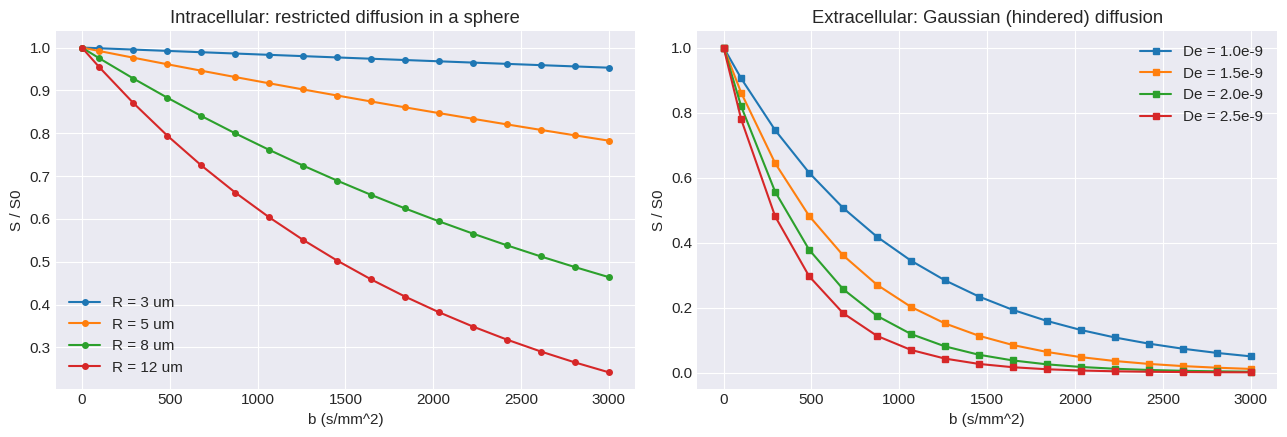

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))

# Intracellular restricted signal for several radii
for R in [3, 5, 8, 12]:
    S = cexi.SPHERE_sig(R, params_tissue['Di'], protocol)
    ax[0].plot(b_values, S, 'o-', ms=4, label=f'R = {R} um')
ax[0].set(title='Intracellular: restricted diffusion in a sphere',
          xlabel='b (s/mm^2)', ylabel='S / S0'); ax[0].legend()

# Extracellular Gaussian signal for several diffusivities  (S = exp(-b*De))
for De in [1.0e-9, 1.5e-9, 2.0e-9, 2.5e-9]:
    S = np.exp(-De * b_values * 1e6)   # b s/mm^2 -> s/m^2
    ax[1].plot(b_values, S, 's-', ms=4, label=f'De = {De*1e9:.1f}e-9')
ax[1].set(title='Extracellular: Gaussian (hindered) diffusion',
          xlabel='b (s/mm^2)', ylabel='S / S0'); ax[1].legend()
plt.tight_layout(); plt.show()

## 6. Exchange: effect of permeability

Increasing $\kappa$ speeds up exchange between the restricted and Gaussian
compartments. The signal moves away from the impermeable ($\kappa=0$) curve.

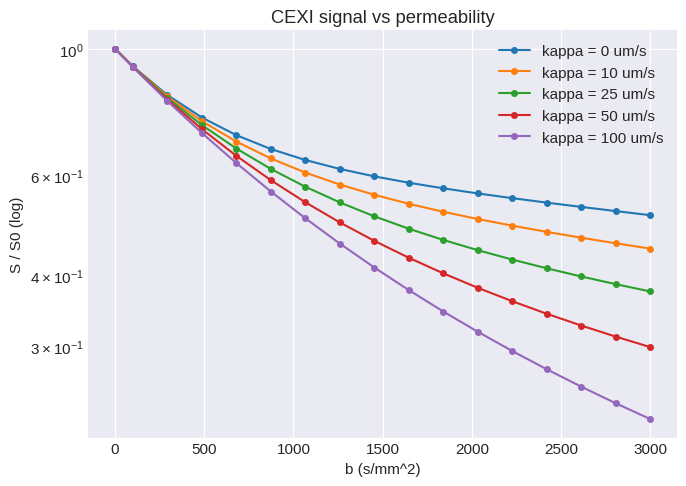

In [5]:
plt.figure(figsize=(7, 5))
p = dict(params_tissue)
for kappa in [0, 10, 25, 50, 100]:
    S = cexi.CEXI_sig(p['R'], p['Di'], p['De'], p['f'], kappa, protocol)
    plt.plot(b_values, S, 'o-', ms=4, label=f'kappa = {kappa} um/s')
plt.yscale('log')
plt.title('CEXI signal vs permeability'); plt.xlabel('b (s/mm^2)')
plt.ylabel('S / S0 (log)'); plt.legend(); plt.tight_layout(); plt.show()

## 7. Time dependence — the exchange signature

Exchange is identified by acquiring **several diffusion times** $\Delta$. Without
exchange the signal is strongly $\Delta$-dependent (restriction); exchange
*reduces* that time dependence. This is why multi-$\Delta$ protocols are used to
estimate $\kappa$.

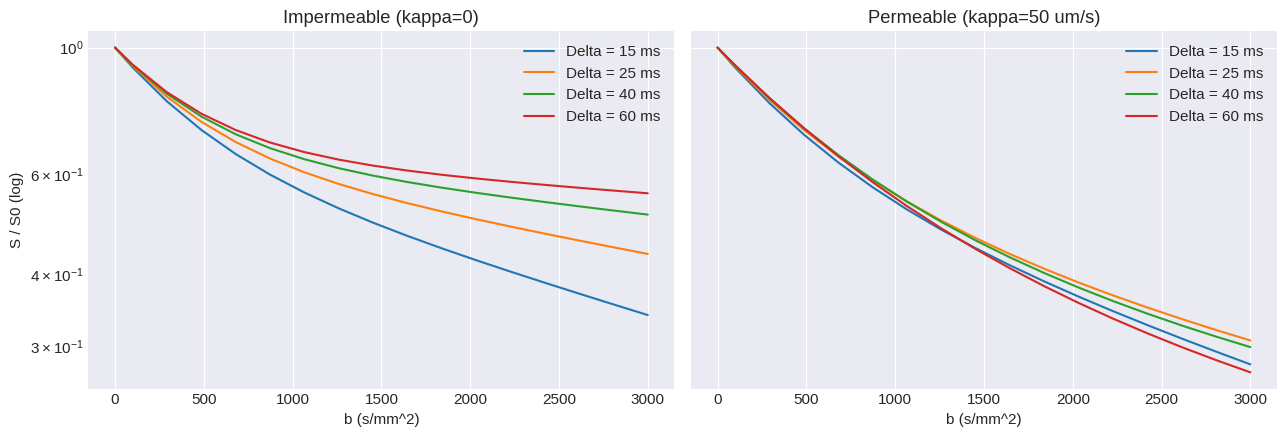

In [6]:
deltas_ms = [15, 25, 40, 60]
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
for kappa, a, ttl in [(0, ax[0], 'Impermeable (kappa=0)'),
                      (50, ax[1], 'Permeable (kappa=50 um/s)')]:
    for D_ms in deltas_ms:
        proto = cexi.Protocol(bvals=b_values, delta=0.010, tdiff=D_ms/1000.0)
        S = cexi.CEXI_sig(params_tissue['R'], params_tissue['Di'], params_tissue['De'],
                          params_tissue['f'], kappa, proto)
        a.plot(b_values, S, '-', label=f'Delta = {D_ms} ms')
    a.set(title=ttl, xlabel='b (s/mm^2)', yscale='log'); a.legend()
ax[0].set_ylabel('S / S0 (log)')
plt.tight_layout(); plt.show()

## 8. Fitting the model

`fit_CEXI` estimates the five parameters from a measured signal by minimizing the
RMSE between the data and the model signal. It uses several random restarts of a
bounded quasi-Newton optimizer (L-BFGS-B), optimizing in a normalized parameter
space so the very different parameter scales (e.g. $R\sim$5 vs $D_i\sim10^{-9}$)
are well conditioned. It returns the best-fit parameters and the fit RMSE.

To make all five parameters identifiable, the fit needs a **multi-$\Delta$**
protocol: the same b-values are acquired at several diffusion times, so that
restriction and exchange can be separated.

In [7]:
# Multi-Delta acquisition: the same b-values at several diffusion times Delta
b_shell  = np.concatenate([[0], np.linspace(500, 3000, 6)])   # s/mm^2
deltas_ms = [15, 25, 40, 60]                                  # diffusion times Delta
bvals_fit = np.tile(b_shell, len(deltas_ms))
tdiff_fit = np.repeat([d/1000.0 for d in deltas_ms], len(b_shell))
protocol_fit = cexi.Protocol(bvals=bvals_fit, delta=0.010, tdiff=tdiff_fit)
print(f"{len(bvals_fit)} measurements = {len(b_shell)} b-values x {len(deltas_ms)} diffusion times")

28 measurements = 7 b-values x 4 diffusion times


In [8]:
# Synthesize a measurement from the ground-truth parameters, add Rician noise
signal_clean = cexi.CEXI_sig(params_tissue['R'], params_tissue['Di'], params_tissue['De'],
                             params_tissue['f'], params_tissue['kappa'], protocol_fit)
rng = np.random.default_rng(0)
SNR = 100
noise = lambda x: np.sqrt((x + rng.normal(0, 1/SNR, x.shape))**2 + rng.normal(0, 1/SNR, x.shape)**2)
signal_noisy = noise(signal_clean)

bounds = {'R': (2.0, 15.0), 'Di': (0.3e-9, 2.0e-9), 'De': (1.0e-9, 3.5e-9),
          'f': (0.3, 0.85), 'kappa': (1.0, 100.0)}
fit, rmse = cexi.fit_CEXI(signal_noisy, protocol_fit, bounds=bounds, n_init=20, seed=0)

print(f"{'param':<7}{'true':>10}{'fitted':>10}")
for k in ['R', 'Di', 'De', 'f', 'kappa']:
    t, v = params_tissue[k], fit[k]
    sc = 1e9 if k in ('Di', 'De') else 1.0
    print(f"{k:<7}{t*sc:>10.2f}{v*sc:>10.2f}")
print(f"\nfit RMSE = {rmse:.4f}")

param        true    fitted
R            5.00      5.01
Di           1.00      0.70
De           2.00      2.09
f            0.65      0.66
kappa       25.00     23.03

fit RMSE = 0.0076


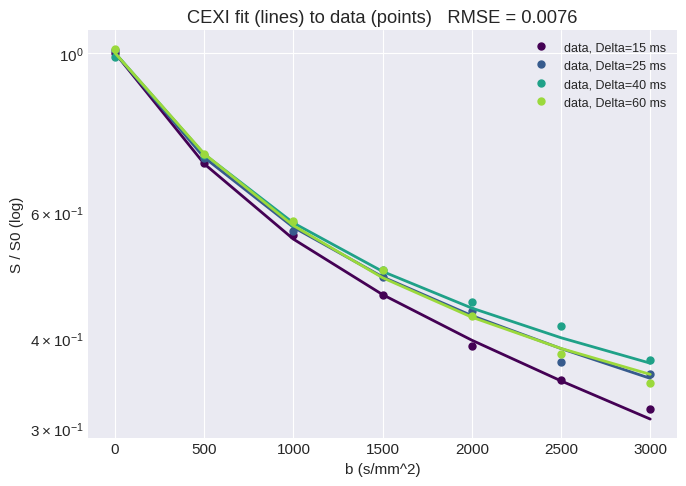

In [9]:
# Overlay the fitted model on the data, one panel per diffusion time
S_fit = cexi.CEXI_sig(fit['R'], fit['Di'], fit['De'], fit['f'], fit['kappa'], protocol_fit)
plt.figure(figsize=(7, 5))
colors = plt.cm.viridis(np.linspace(0, 0.85, len(deltas_ms)))
for j, D_ms in enumerate(deltas_ms):
    m = tdiff_fit == D_ms/1000.0
    plt.plot(b_shell, signal_noisy[m], 'o', color=colors[j], ms=5,
             label=f'data, Delta={D_ms} ms')
    plt.plot(b_shell, S_fit[m], '-', color=colors[j], lw=2)
plt.yscale('log'); plt.xlabel('b (s/mm^2)'); plt.ylabel('S / S0 (log)')
plt.title(f'CEXI fit (lines) to data (points)   RMSE = {rmse:.4f}')
plt.legend(fontsize=9); plt.tight_layout(); plt.show()

## 9. Summary

- **Model**: two compartments — a restricted sphere (intracellular) and a
  Gaussian medium (extracellular) — coupled by **Kärger water exchange**.
- **Parameters**: $R$, $D_i$, $D_e$, $f$, $\kappa$. Exchange is set by
  $k_i = 3\kappa/R$ (residence time $\tau_i = R/(3\kappa)$) with
  $k_e = k_i\,f/(1-f)$ by detailed balance.
- **Acquisition**: use a range of b-values **and several diffusion times**
  $\Delta$ — exchange is seen as a reduction of the time dependence of the signal.
- **Fitting**: `fit_CEXI` returns the five parameters and the fit RMSE via
  multi-start bounded optimization in a normalized parameter space.